In [1]:
import pandas as pd

df = pd.read_csv('C:/Users/Asus/Desktop/dl_lab/samples/healthcare_dataset.csv')

print(df.columns.tolist())

['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Load Dataset
df = pd.read_csv('C:/Users/Asus/Desktop/dl_lab/samples/healthcare_dataset.csv')

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

# Encode categorical columns
for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col])

# Target Column
target_column = "target"   # Change if needed

# Features and Target
target_column = "Test Results"
X = df.drop(columns=[target_column])
y = df[target_column]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM Model
model = SVC(kernel='rbf')

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

# Save Model
joblib.dump(model, "disease_svm_model.pkl")

print("Model Saved Successfully")

Dataset Shape: (55500, 15)
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
Accuracy: 34.60978715663089
Model Saved Successfully


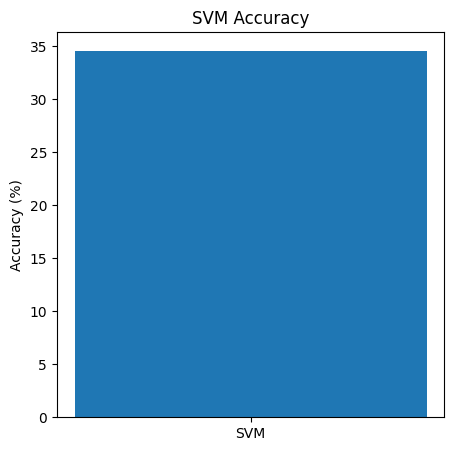

In [6]:
plt.figure(figsize=(5,5))

plt.bar(["SVM"], [accuracy * 100])

plt.ylabel("Accuracy (%)")
plt.title("SVM Accuracy")

plt.show()

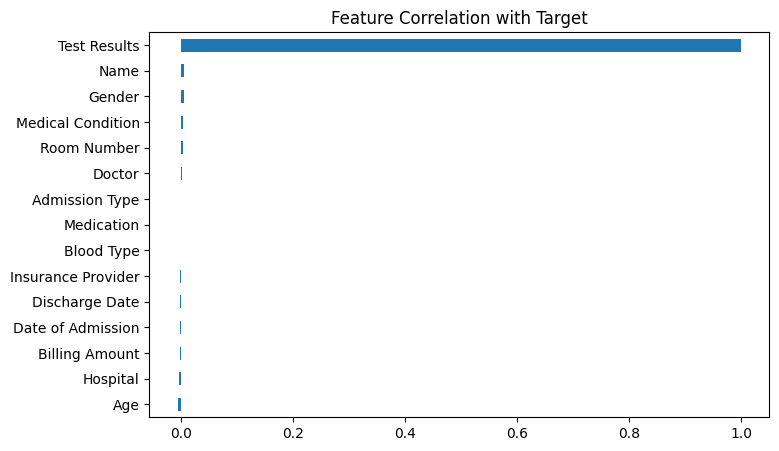

In [7]:
corr = df.corr(numeric_only=True)

corr[target_column].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Correlation with Target")

plt.show()

In [8]:
print(df.columns.tolist())

['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
